# TERRAPYGE: DEM Exploration Notebook

This notebook explores the Digital Elevation Model (DEM) data for Cebu City downloaded from Google Earth Engine.

## 1. Import Libraries

In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## 2. Load DEM Data

In [2]:
# Define DEM path
dem_path = Path.cwd() / 'data' / 'raw' / 'dem' / 'CebuCity_DEM.tif'

# Load DEM
with rasterio.open(dem_path) as src:
    dem = src.read(1)
    profile = src.profile
    
    print(f"DEM Shape: {dem.shape}")
    print(f"Resolution: {profile['transform']}")
    print(f"CRS: {profile['crs']}")
    print(f"Elevation Range: {dem.min():.2f} - {dem.max():.2f} m")
    print(f"No-data value: {profile.get('nodata', 'None')}")

DEM Shape: (743, 743)
Resolution: | 0.00, 0.00, 123.80|
| 0.00,-0.00, 10.40|
| 0.00, 0.00, 1.00|
CRS: EPSG:4326
Elevation Range: -15.00 - 755.00 m
No-data value: None


## 3. Visualize DEM

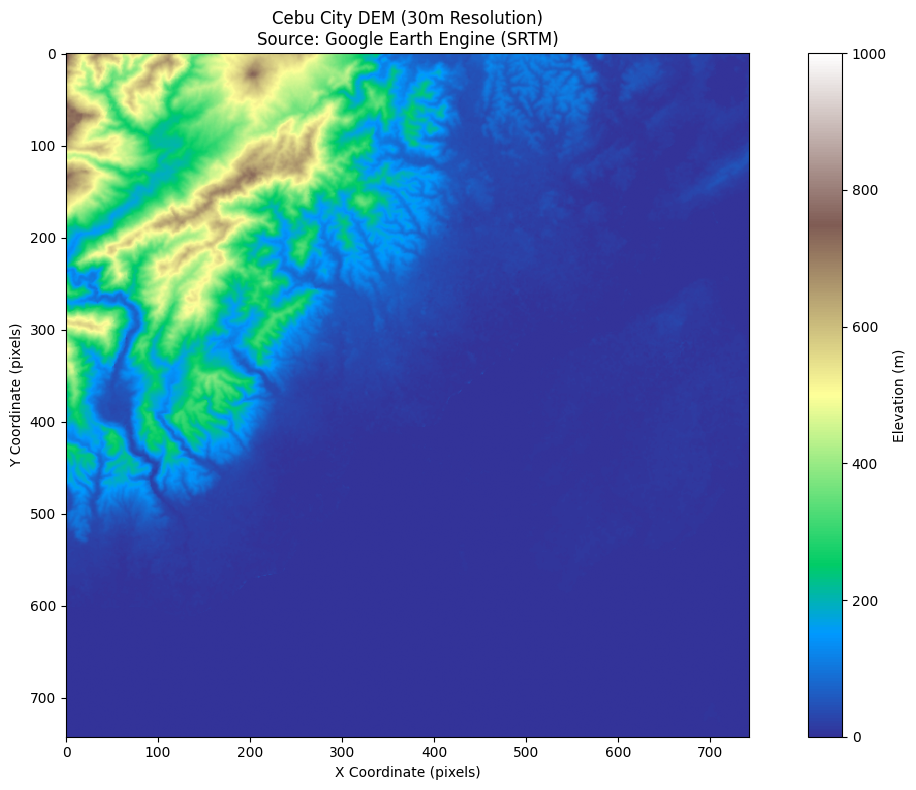

In [3]:
# Create figure
plt.figure(figsize=(12, 8))

# Plot DEM
im = plt.imshow(dem, cmap='terrain', vmin=0, vmax=1000)
plt.colorbar(im, label='Elevation (m)')
plt.title('Cebu City DEM (30m Resolution)\nSource: Google Earth Engine (SRTM)')
plt.xlabel('X Coordinate (pixels)')
plt.ylabel('Y Coordinate (pixels)')
plt.tight_layout()
plt.show()

## 4. Basic Statistics

In [4]:
# Remove no-data values
nodata = profile.get('nodata', -9999)
dem_valid = dem[dem != nodata]

# Calculate statistics
stats = {
    'Mean': np.mean(dem_valid),
    'Std': np.std(dem_valid),
    'Min': np.min(dem_valid),
    'Max': np.max(dem_valid),
    'Median': np.median(dem_valid),
    '25th Percentile': np.percentile(dem_valid, 25),
    '75th Percentile': np.percentile(dem_valid, 75)
}

print("DEM Statistics (meters):")
for key, value in stats.items():
    print(f"  {key}: {value:.2f}")

print(f"\nValid pixels: {len(dem_valid):,} / {dem.size:,} ({len(dem_valid)/dem.size*100:.1f}%)")

DEM Statistics (meters):
  Mean: 89.68
  Std: 154.54
  Min: -15.00
  Max: 755.00
  Median: 8.00
  25th Percentile: 0.00
  75th Percentile: 112.00

Valid pixels: 552,049 / 552,049 (100.0%)


## 5. Elevation Distribution

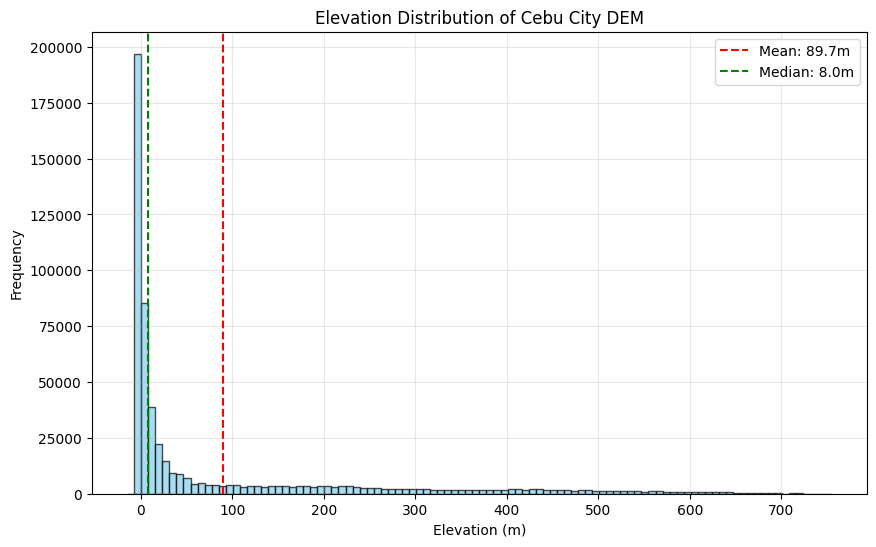

In [5]:
# Plot elevation distribution
plt.figure(figsize=(10, 6))
plt.hist(dem_valid, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(dem_valid), color='red', linestyle='--', label=f'Mean: {np.mean(dem_valid):.1f}m')
plt.axvline(np.median(dem_valid), color='green', linestyle='--', label=f'Median: {np.median(dem_valid):.1f}m')
plt.xlabel('Elevation (m)')
plt.ylabel('Frequency')
plt.title('Elevation Distribution of Cebu City DEM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. 3D Visualization (Optional)

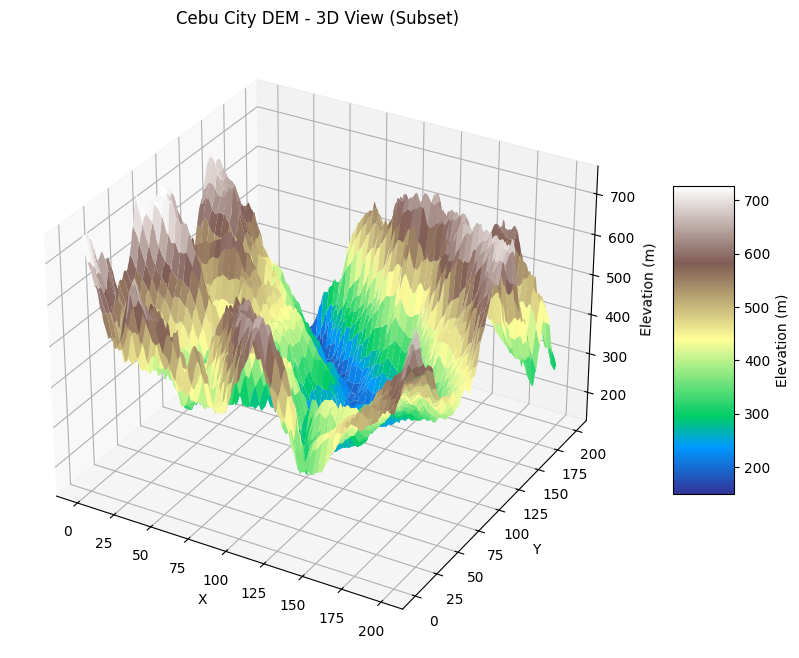

In [6]:
# Create a subset for faster 3D visualization
subset_size = 200
dem_subset = dem[:subset_size, :subset_size]

# Create meshgrid
x = np.arange(dem_subset.shape[1])
y = np.arange(dem_subset.shape[0])
X, Y = np.meshgrid(x, y)

# Plot 3D surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, dem_subset, cmap='terrain', linewidth=0, antialiased=True)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Elevation (m)')
ax.set_title('Cebu City DEM - 3D View (Subset)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Elevation (m)')
plt.show()

## 7. Save Statistics to File

In [7]:
# Save statistics to text file
stats_file = Path.cwd() / 'results' / 'dem_statistics.txt'
stats_file.parent.mkdir(parents=True, exist_ok=True)

with open(stats_file, 'w') as f:
    f.write("Cebu City DEM Statistics\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Source: Google Earth Engine (SRTM 30m)\n")
    f.write(f"Date: {np.datetime64('today')}\n\n")
    f.write("Statistics (meters):\n")
    for key, value in stats.items():
        f.write(f"  {key}: {value:.2f}\n")
    f.write(f"\nValid pixels: {len(dem_valid):,} / {dem.size:,} ({len(dem_valid)/dem.size*100:.1f}%)\n")
    f.write(f"DEM Shape: {dem.shape}\n")
    f.write(f"CRS: {profile['crs']}\n")

print(f"Statistics saved to: {stats_file}")

Statistics saved to: D:\TERRAPYGE\results\dem_statistics.txt


## 8. Next Steps

### Phase 2: Data Preprocessing
1. **Condition DEM**: Fill pits and depressions using pysheds or whitebox
2. **Calculate slope and aspect**: Using terrain analysis
3. **Extract slope units**: Using r.slopeunits algorithm

### Phase 3: Graph Construction
1. **Create node features**: Aggregate MGB and BSWM data to slope units
2. **Build spatial edges**: Queen/Rook contiguity
3. **Build hydrological edges**: D8 flow routing
4. **Create PyG graph**: Convert to PyTorch Geometric format

### Phase 4: GNN Modeling
1. **Implement baselines**: Logistic Regression, Random Forest
2. **Build GNN models**: GCN, GraphSAGE, GAT
3. **Train and evaluate**: Compare performance
4. **Generate hazard maps**: Visualize predictions